# Chapter 1

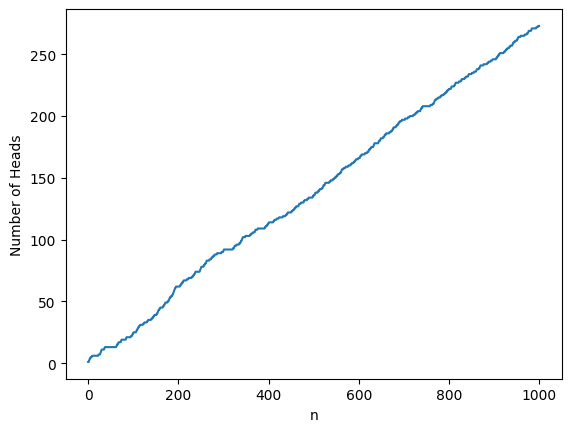

In [1]:
# Task 21
import numpy as np
import matplotlib.pyplot as plt
p = 0.3
heads = []
for i  in range(1001):
    z = np.random.rand() 
    if z < p:
        heads.append(1)
    else:
        heads.append(0)

hd = np.cumsum(heads)


plt.plot(hd, label='Number of Heads')
plt.xlabel('n')
plt.ylabel('Number of Heads')
plt.show()

At n: 10: 8.9965
Theory np: 9.0
Difference 0.0035000000000007248

At n: 100: 90.0384
Theory np: 90.0
Difference 0.03839999999999577

At n: 1000: 899.8454
Theory np: 900.0
Difference 0.15459999999995944



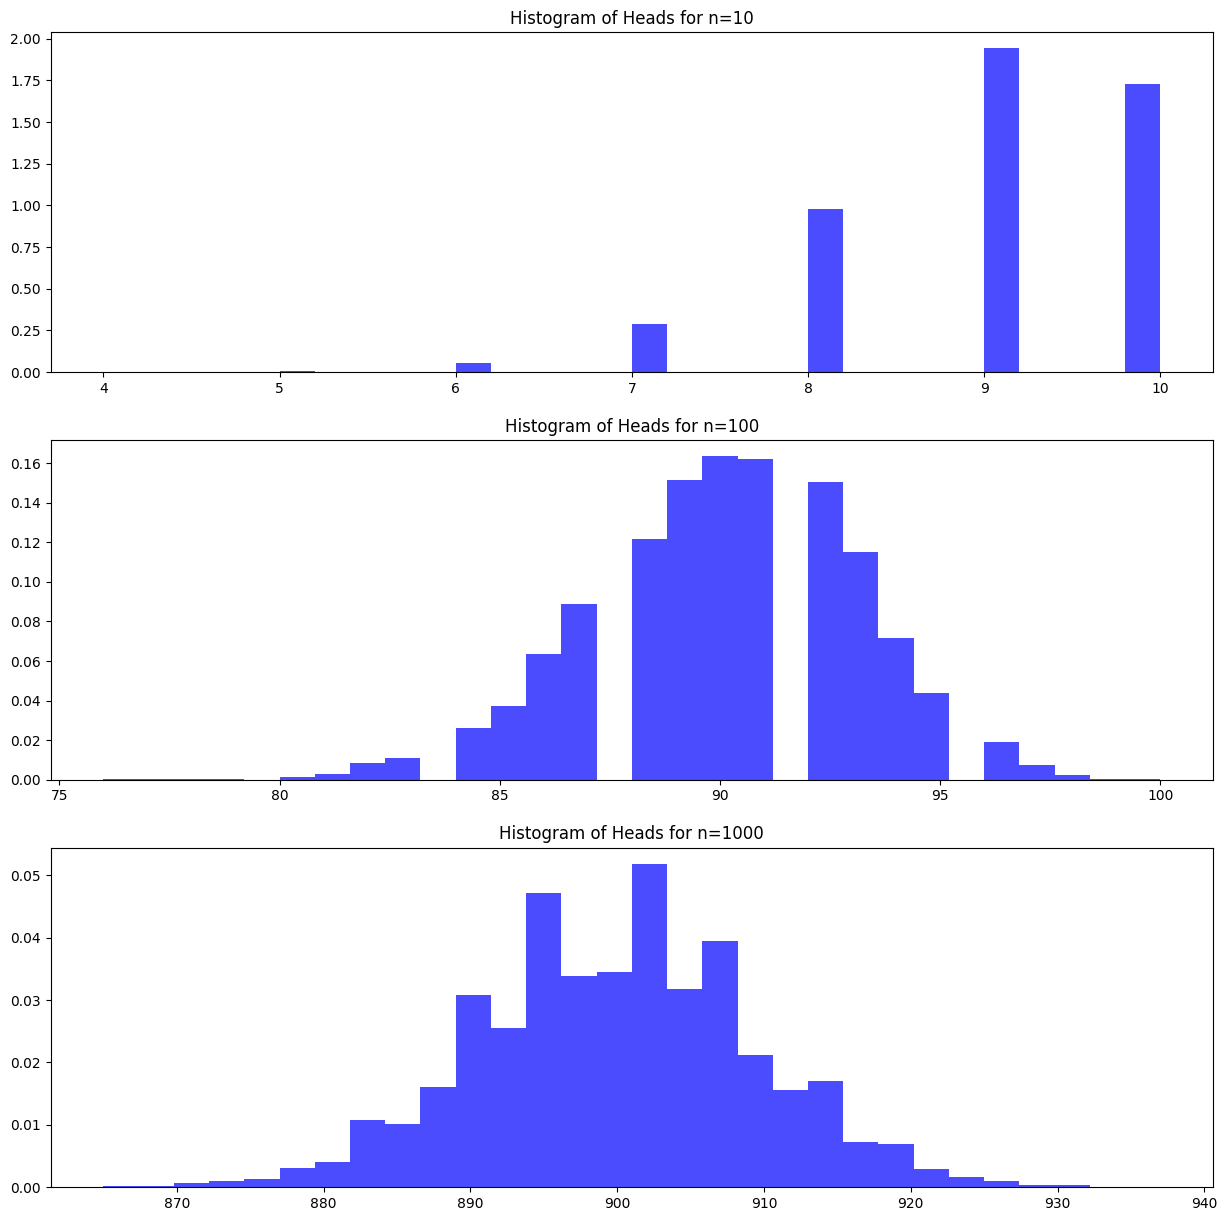

In [2]:
# Task 22

p = 0.9
ns = [10, 100, 1000]
plt.figure(figsize=(15, 15))
plt.subplot(3, 1, 1)
for n in ns:

    general_heads = []
    for i in range(10000):
        heads = 0
        for i in range(n):
            z = np.random.rand()
            if z < p:
                heads += 1
        general_heads.append(heads)
    
    plt.subplot(3, 1, ns.index(n)+1)
    plt.hist(general_heads, bins=30, density=True, alpha=0.7, color='blue')
    plt.title(f'Histogram of Heads for n={n}')
    
    
    average = sum(general_heads)/len(general_heads)

    print(f"At n: {n}: {average}")
    print(f"Theory np: {n*p}")
    print(f"Difference {np.abs(average - n*p)}\n")


In [3]:
# Task 23

res = [1,2,3,4,5,6]
n = 10000
A = 0
B = 0

for i in range(n):
    c = np.random.choice(res)
    if c in [2,4,6]:
        A += 1
    if c in [1,2,3,4]:
        B += 1
print(f"Probability of A: {A/n}")
print(f"Probability of B: {B/n}")


Probability of A: 0.4981
Probability of B: 0.6717


In [4]:
# 1. Setup the experiment
n_simulations = 100_000
rolls = np.random.randint(1, 7, n_simulations)  # Roll a die (1-6) n times

# 2. Define the Events
# Event A: Number is <= 3
event_a = (rolls <= 3)

# Event B: Number is Even (rolls % 2 == 0)
event_b = (rolls % 2 == 0)

# Event A AND B: Both conditions are true
event_a_and_b = (event_a & event_b)

# 3. Calculate Probabilities (Proportions)
# The mean of a boolean array gives the proportion of Trues
prob_a_sim = np.mean(event_a)
prob_b_sim = np.mean(event_b)
prob_ab_sim = np.mean(event_a_and_b)

# 4. Calculate Theoretical Values for comparison
prob_a_theo = 3/6
prob_b_theo = 3/6
prob_ab_theo = 1/6 

# 5. Report Results
print(f"{'Metric':<20} | {'Simulated':<10} | {'Theoretical':<10}")
print("-" * 46)
print(f"{'P(A)':<20} | {prob_a_sim:<10.4f} | {prob_a_theo:<10.4f}")
print(f"{'P(B)':<20} | {prob_b_sim:<10.4f} | {prob_b_theo:<10.4f}")
print(f"{'P(AB)':<20} | {prob_ab_sim:<10.4f} | {prob_ab_theo:<10.4f}")
print("-" * 46)

Metric               | Simulated  | Theoretical
----------------------------------------------
P(A)                 | 0.4995     | 0.5000    
P(B)                 | 0.5009     | 0.5000    
P(AB)                | 0.1662     | 0.1667    
----------------------------------------------


In [1]:
from scipy.stats import norm
# inverse of normal cdf

#c 3+norm.ppf(0.95)*4
#d 
# norm.cdf(1/4) - norm.cdf(-3/4) OR
# norm.cdf(4, loc=3, scale=4) - norm.cdf(0, loc=3, scale=4)
norm.cdf(-1)


np.float64(0.15865525393145707)

# Chapter 3

Text(0, 0.5, 'Average of samples')

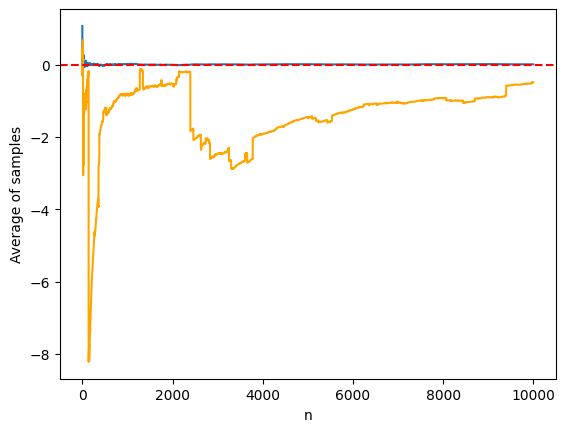

In [28]:
# task 9


xs = []
avgs = []
x_cauchy = []
avgs_cauchy = []
for i in range(1,10000):
    z = np.random.normal(0,1)
    xs.append(z)
    avgs.append(np.mean(xs))
    z_c = np.random.standard_cauchy()
    x_cauchy.append(z_c)
    avgs_cauchy.append(np.mean(x_cauchy))

plt.plot(avgs)
plt.plot(avgs_cauchy, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('n')
plt.ylabel('Average of samples')



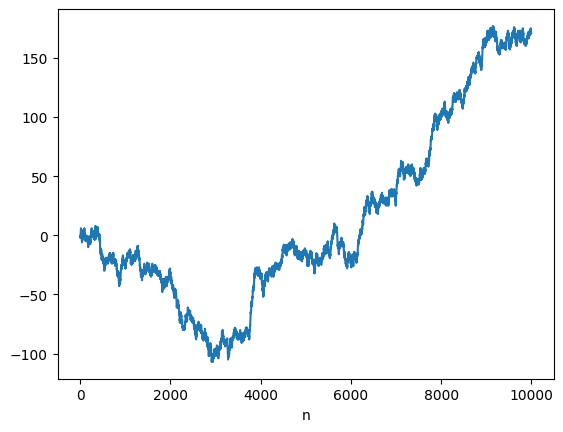

In [32]:
# Task 11

# P(y=1) = p(y=-1) = 0.4
# Xn = sum(yi)

ys = []
xs = []
for i in range(1,10_000):
    y = np.random.choice([-1,1])
    ys.append(y)
    xs.append(np.sum(ys))

plt.plot(xs)
plt.xlabel('n')
plt.show()


# CHapter 7

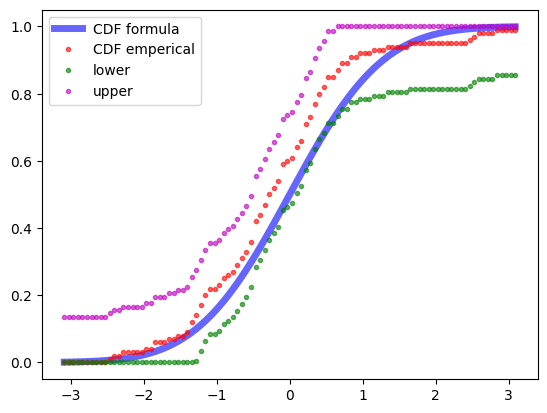

Normal dist. : percentage of times bounds dont contain true F:  0.032


In [20]:
# Chapter 7, problem 3, Normal distribution
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def ecdf(data, x_vec, alpha):
    data_sort = np.sort(data)
    n = data.size
    eps = np.sqrt(np.log(2/alpha)/(2*n))
    F_hat = []
    F_lower = []
    F_upper = []
    for e in x_vec:
        if e >= data_sort[-1]:
            tmp = 1
        elif e < data_sort[0]:
            tmp = 0
        else:
            idx = np.argwhere(np.array(data_sort) > e)[0][0]
            tmp = idx/n
        
        F_hat.append(tmp)
        F_lower.append(max(tmp-eps, 0))
        F_upper.append(min(tmp+eps, 1))
    return F_hat, F_lower, F_upper

x_vec = np.linspace(norm.ppf(0.001), norm.ppf(0.999), 100)
F_real = norm.cdf(x_vec)

data = np.random.normal(0, 1, 100)
F_hat, F_lower, F_upper = ecdf(data, x_vec, alpha = 0.05)

plt.plot(x_vec, F_real, 'b-', lw=5, alpha=0.6, label='CDF formula')
plt.plot(x_vec, F_hat, 'r.', lw=5, alpha=0.6, label='CDF emperical')
plt.plot(x_vec, F_lower, 'g.', lw=5, alpha=0.6, label='lower')
plt.plot(x_vec, F_upper, 'm.', lw=5, alpha=0.6, label='upper')
plt.legend(loc='best')
plt.show()

cnt = 0
sim_num = 1000
for i in range(sim_num):
    data = np.random.normal(0, 1, 100)
    F_hat, F_lower, F_upper = ecdf(data, x_vec, alpha = 0.05)
    for j in range(F_real.size):
        if (F_real[j] > F_upper[j]) or (F_real[j] < F_lower[j]):
            cnt += 1
            break

print('Normal dist. : percentage of times bounds dont contain true F: ', cnt/sim_num) 

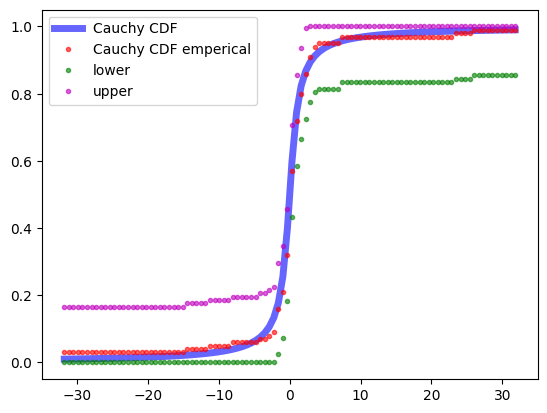

Cauchy dist. : percentage of times bounds dont contain true F:  0.011


In [16]:
# Chapter 7, problem 3, Cauchy distribution
from scipy.stats import cauchy

x_vec = np.linspace(cauchy.ppf(0.01), cauchy.ppf(0.99), 100)
F_real = cauchy.cdf(x_vec)

data = np.random.standard_cauchy(100)
F_hat, F_lower, F_upper = ecdf(data, x_vec, alpha = 0.05)

plt.plot(x_vec, F_real, 'b-', lw=5, alpha=0.6, label='Cauchy CDF')
plt.plot(x_vec, F_hat, 'r.', lw=5, alpha=0.6, label='Cauchy CDF emperical')
plt.plot(x_vec, F_lower, 'g.', lw=5, alpha=0.6, label='lower')
plt.plot(x_vec, F_upper, 'm.', lw=5, alpha=0.6, label='upper')
plt.legend(loc='best')
plt.show()

cnt = 0
sim_num = 1000
for i in range(sim_num):
    data = np.random.standard_cauchy(100)
    F_hat, F_lower, F_upper = ecdf(data, x_vec, alpha = 0.05)
    for j in range(F_real.size):
        if (F_real[j] > F_upper[j]) or (F_real[j] < F_lower[j]):
            cnt += 1
            break

print('Cauchy dist. : percentage of times bounds dont contain true F: ', cnt/sim_num) 

In [21]:
import numpy as np
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt

# uploaded = files.upload()
df = pd.read_csv('https://raw.githubusercontent.com/sajad13901/Statistics_Wasserman/main/fiji.txt', delimiter= '\s+', index_col=False)

def ecdf(data, x_vec, alpha):
    data_sort = np.sort(data)
    n = data.size
    eps = (np.log(2/alpha)/n/2) ** .5
    F_hat, F_lower, F_upper  = [], [], []
    for e in x_vec:
        if e >= data_sort[-1]: tmp = 1
        elif e < data_sort[0]: tmp = 0
        else:
            idx = np.argwhere(np.array(data_sort) > e)[0][0]
            tmp = idx/n        
        F_hat.append(tmp)
        F_lower.append(max(tmp-eps, 0))
        F_upper.append(min(tmp+eps, 1))
    return F_hat, F_lower, F_upper

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mkami\AppData\Local\Temp\ipykernel_3020\3737847175.py:7: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('https://raw.githubusercontent.com/sajad13901/Statistics_Wasserman/main/fiji.txt', delimiter= '\s+', index_col=False)


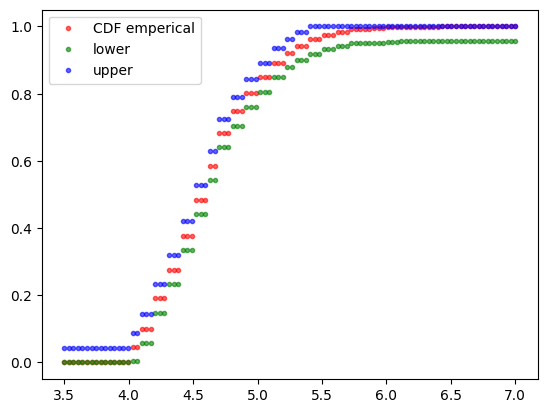

95% interval:  0.495 , 0.557


In [25]:
x_vec = np.linspace(3.5, 7, 100)
data = df.mag
F_hat, F_lower, F_upper = ecdf(data, x_vec, alpha = 0.05)

plt.plot(x_vec, F_hat, 'r.', lw=5, alpha=0.6, label='CDF emperical')
plt.plot(x_vec, F_lower, 'g.', lw=3, alpha=0.6, label='lower')
plt.plot(x_vec, F_upper, 'b.', lw=3, alpha=0.6, label='upper')
plt.legend(loc='best')
plt.show()

def calc_F_hat(data, x_val):
    data_sort = np.sort(data)
    if x_val >= data_sort[-1]: return 1
    elif x_val < data_sort[0]: return 0
    else:
        idx = np.argwhere(np.array(data_sort) > x_val)[0][0]
        return (idx/data.size)

a, b = 4.3, 4.9
theta_hat = calc_F_hat(data, b) - calc_F_hat(data, a) 
se = (theta_hat * (1-theta_hat)/data.size) ** .5
z_95 = norm.ppf(.975)
print('95% interval: ', round(theta_hat-z_95*se,3), ',', round(theta_hat+z_95*se,3))

# Chapter 22

In [ ]:
# task 3

In [ ]:
# task 5

# Chapter 6 from lecture notes

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Part 1: Implement the Linear Congruential Generator ---
class LinearCongruentialGenerator:
    def __init__(self, seed, a, b, M):
        self.state = seed
        self.a = a
        self.b = b
        self.M = M

    def next(self):
        # The core LCG formula
        self.state = (self.a * self.state + self.b) % self.M
        # Normalize to [0, 1]
        return self.state / self.M

    def generate_batch(self, n):
        return [self.next() for _ in range(n)]

Test Parameters: n=1000, alpha=0.05
Max Distance (Dn):     0.02770
Critical Threshold:    0.04295

✅ PASSED: The generator produces a valid Uniform distribution.


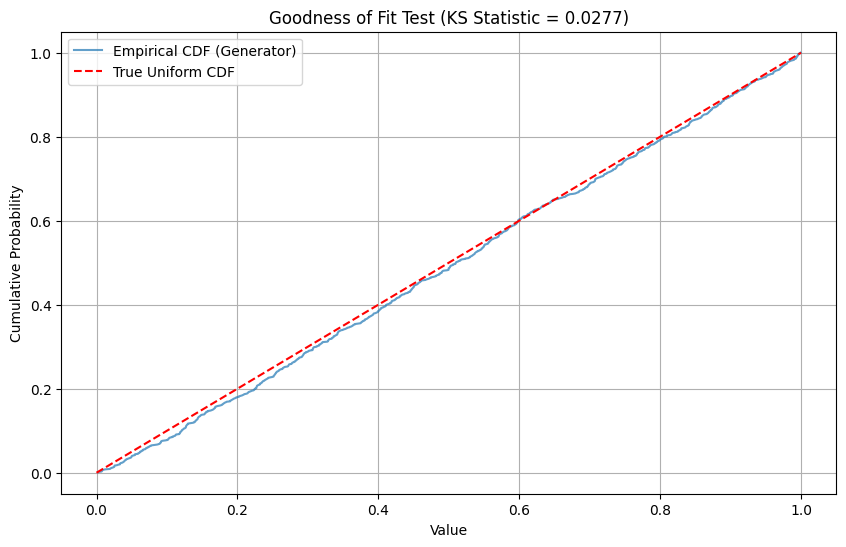

In [2]:
# Configuration that generally works well (Numerical Recipes constants)
# You can try changing these to see the test fail (e.g., a=5, b=1, M=16)
lcg = LinearCongruentialGenerator(seed=42, a=1664525, b=1013904223, M=2**32)

# Generate pseudo-random numbers
n = 1000
random_numbers = np.array(lcg.generate_batch(n))

# --- Part 2: The Statistical Test (DKW) ---

# 1. Sort the data to calculate Empirical CDF
data_sorted = np.sort(random_numbers)

# 2. Define the Empirical CDF (Fn) values
# Fn(x) jumps by 1/n at each data point
y_vals = np.arange(1, n + 1) / n

# 3. Define the True Uniform CDF F(x)
# For Uniform[0,1], F(x) = x. 
# We compare at the data points.
true_cdf_vals = data_sorted

# 4. Calculate the KS Statistic (Supremum distance)
# We check the distance just before the jump and just after the jump
dist_plus = np.abs(y_vals - true_cdf_vals)
dist_minus = np.abs((y_vals - 1/n) - true_cdf_vals)
Dn = np.max(np.maximum(dist_plus, dist_minus))

# 5. Calculate the DKW Critical Value (epsilon)
alpha = 0.05  # 95% confidence
epsilon = np.sqrt((1 / (2 * n)) * np.log(2 / alpha))

# --- Report Results ---
print(f"Test Parameters: n={n}, alpha={alpha}")
print(f"Max Distance (Dn):     {Dn:.5f}")
print(f"Critical Threshold:    {epsilon:.5f}")

if Dn <= epsilon:
    print("\n✅ PASSED: The generator produces a valid Uniform distribution.")
else:
    print("\n❌ FAILED: The generator does NOT look Uniform.")

# --- Visualization (Optional but helpful) ---
plt.figure(figsize=(10, 6))
plt.plot(data_sorted, y_vals, label='Empirical CDF (Generator)', alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--', label='True Uniform CDF')
plt.title(f'Goodness of Fit Test (KS Statistic = {Dn:.4f})')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
def box_muller_transform(uniform_data, mu, sigma):
    """
    Takes a list of uniform values and converts them to 
    Normal(mu, sigma^2) using the Box-Muller method.
    """
    normal_samples = []
    
    # Process in pairs
    for i in range(0, len(uniform_data), 2):
        u1 = uniform_data[i]
        u2 = uniform_data[i+1]
        
        # Avoid log(0)
        if u1 == 0: u1 = 1e-10
            
        # Standard Normal Z ~ N(0, 1)
        z0 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
        z1 = np.sqrt(-2 * np.log(u1)) * np.sin(2 * np.pi * u2)
        
        # Scale to N(mu, sigma)
        # X = z * std_dev + mean
        normal_samples.append(z0 * sigma + mu)
        normal_samples.append(z1 * sigma + mu)
        
    return np.array(normal_samples)

In [5]:
from scipy import stats
# --- 3. The Experiment ---
# Setup
n = 1000
lcg = LinearCongruentialGenerator(seed=42, a=1664525, b=1013904223, M=2**32)

# Generate Uniforms
uniforms = lcg.generate_batch(n)

# Convert to Normal(10, 5). 
# Assuming notation N(mu, variance), so std_dev = sqrt(5)
target_mu = 10
target_var = 5
target_sigma = np.sqrt(target_var)

data = box_muller_transform(uniforms, target_mu, target_sigma)

# --- 4. The Test (DKW / KS Statistic) ---
# Sort data for Empirical CDF
data_sorted = np.sort(data)
y_vals = np.arange(1, len(data) + 1) / len(data)

# Calculate theoretical CDF values for N(10, 5)
cdf_theoretical = stats.norm.cdf(data_sorted, loc=target_mu, scale=target_sigma)

# Calculate KS Statistic (Dn)
dist_plus = np.abs(y_vals - cdf_theoretical)
dist_minus = np.abs((y_vals - 1/n) - cdf_theoretical)
Dn = np.max(np.maximum(dist_plus, dist_minus))

# Calculate Critical Value (epsilon) for alpha = 0.05
alpha = 0.05
epsilon = np.sqrt((1 / (2 * n)) * np.log(2 / alpha))

# Report
print(f"KS Statistic (Dn):  {Dn:.5f}")
print(f"Critical Threshold: {epsilon:.5f}")

if Dn <= epsilon:
    print("✅ PASSED: The data is consistent with N(10, 5).")
else:
    print("❌ FAILED: The data does not look like N(10, 5).")

KS Statistic (Dn):  0.01885
Critical Threshold: 0.04295
✅ PASSED: The data is consistent with N(10, 5).


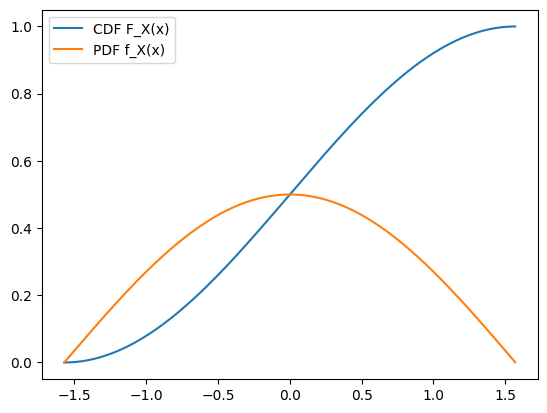

In [11]:
# task 6.20

F_X = lambda x: 0.5*(np.sin(x) + 1)
f_x = lambda x: 0.5*np.cos(x)
F_inv_X = lambda u: np.arcsin(2*u - 1)

x = np.arange(-np.pi/2, np.pi/2, 0.01)

plt.plot(x, F_X(x), label='CDF F_X(x)')
plt.plot(x, f_x(x), label='PDF f_X(x)')
plt.legend(loc='best')
plt.show()


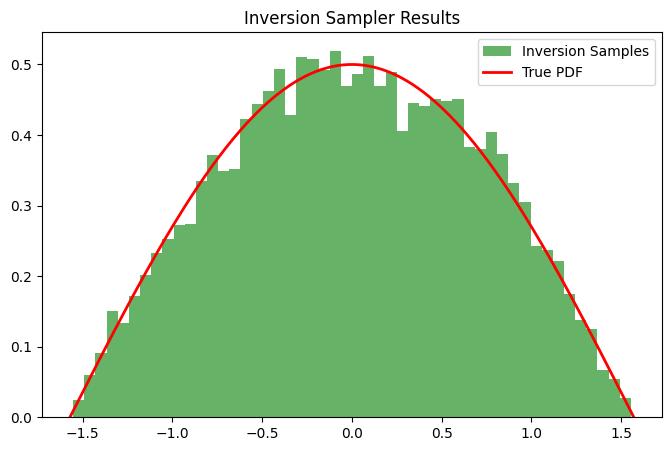

In [13]:
def inversion_sampler(n):
    u_samples = np.random.uniform(0,1,n)
    x_samples = F_inv_X(u_samples)
    return x_samples

# Generate and visualize inversion samples
inv_samples = inversion_sampler(10000)
plt.figure(figsize=(8, 5))
plt.hist(inv_samples, bins=50, density=True, alpha=0.6, color='green', label='Inversion Samples')
plt.plot(x, f_x(x), 'r-', lw=2, label='True PDF')
plt.title('Inversion Sampler Results')
plt.legend()
plt.show()

In [14]:
# --- 4. Accept-Reject Sampler ---
def accept_reject_sampler(n):
    samples = []
    rejected_count = 0
    
    # Proposal distribution g(x) is Uniform(-pi/2, pi/2)
    # The length of interval is pi, so g(x) = 1/pi
    # We need M such that M*g(x) >= p(x)
    # Max of p(x) is 0.5. Max of g(x) is 1/pi.
    # M * (1/pi) >= 0.5  -->  M >= pi/2
    M = np.pi / 2
    
    while len(samples) < n:
        # 1. Generate candidate from Uniform(-pi/2, pi/2)
        candidate = np.random.uniform(-np.pi/2, np.pi/2)
        
        # 2. Generate decision variable u
        u = np.random.uniform(0, 1)
        
        # 3. Calculate acceptance ratio
        # ratio = p(candidate) / (M * g(candidate))
        # p(x) = 0.5 * cos(x)
        # M * g(x) = (pi/2) * (1/pi) = 0.5
        # ratio = (0.5 * cos(x)) / 0.5 = cos(x)
        
        if u <= np.cos(candidate):
            samples.append(candidate)
        else:
            rejected_count += 1
            
    return np.array(samples), rejected_count

# Run Accept-Reject
n_samples = 10000
ar_samples, rejections = accept_reject_sampler(n_samples)

# --- Calculations for the final question ---
total_trials = n_samples + rejections
rejection_rate = rejections / total_trials
theoretical_rejection_rate = 1 - (2 / np.pi)

print(f"Total Samples Generated: {n_samples}")
print(f"Total Rejections: {rejections}")
print(f"Empirical Rejection Rate: {rejection_rate:.4f}")
print(f"Theoretical Rejection Rate: {theoretical_rejection_rate:.4f}")

Total Samples Generated: 10000
Total Rejections: 5720
Empirical Rejection Rate: 0.3639
Theoretical Rejection Rate: 0.3634


# Sample exam problem from 13-High dimension


The goal of this problem is to implement your own random projection function, i.e. same as in the random projection theorem and Johnson Lindenstrauss. Below you will find a function template, as always fill in XXX.


Some notes, the input will be a numpy array and the output should also be a numpy array. The format for the input is `(n_samples, d)` and the output should be of the form `(n_samples, k)`. 



The Johnson-Lindenstrauss Lemma states that you can project points from a high-dimensional space into a lower-dimensional space while preserving the Euclidean distances between them with high probability.

Here is the breakdown of the implementation steps:
1. The Transformation Matrix (R)

To go from d dimensions to k dimensions, we need a linear transformation. In linear algebra, this is represented by a matrix with d rows (to match the input) and k columns (to produce the output). We fill this matrix with random numbers drawn from a Gaussian (Normal) distribution (μ=0,σ=1).
2. The Projection (X⋅R)

We perform matrix multiplication between your input data X (shape n_samples, d) and the random matrix R (shape d, k).

    The inner dimensions (d) cancel out.

    The resulting shape is (n_samples, k).

3. The Scaling (k​1​)

This is the most strictly mathematical part. If you just sum up k random Gaussian variables squared, the resulting magnitude grows as k increases. To make sure the distances in the new lower-dimensional space resemble the distances in the original space, we must normalize the result. The scaling factor for Gaussian random projections is k​1​.

In [ ]:
# Do not rename the function below just replace what is XXX
def random_projection(X,d,k):
    '''Perform a random projection of the dataset X from 
    d-dimensions into k-dimensions'''
    assert X.shape[1] == d, "The array X does not have the shape (n_samples,d)"
    # 2. Generate a random matrix R of shape (d, k)
    # The entries are drawn from a standard normal distribution N(0, 1)
    R = np.random.normal(loc=0, scale=1, size=(d, k))
    
    # 3. Project the data and scale it
    # We multiply X by R and divide by sqrt(k) to preserve distance magnitudes
    X_new = np.dot(X, R) / np.sqrt(k)
    return X_new